# Block 15 — Asymmetric Systemic-Risk Overlay: Fast De-Risking, State-Dependent Re-Risking

## Purpose

Block 14 established that the daily **sector-correlation + VIX** overlay materially improved risk-adjusted performance:

- CAGR fell only modestly,
- volatility fell sharply,
- maximum drawdown was roughly halved,
- Sharpe, Sortino and Calmar improved materially.

Its remaining weakness is symmetric persistence: once correlation and VIX remain elevated, the portfolio can stay at 25% or 50% exposure even after the weekly state engine begins identifying a genuine recovery.

Block 15 therefore tests an **asymmetric architecture**:

> **Fast de-risking is controlled by the daily systemic-risk overlay. Re-risking is accelerated only by new information from the frozen weekly sector state machine.**

Blocks 1–14 are not altered.

---

## Canonical Block 15 rule

1. Daily correlation + VIX trigger remains exactly as in Block 14.
2. On entry into a stress regime:
   - normal Block-14 defensive exposure applies immediately on the next session,
   - no re-risking is allowed from stale pre-crisis weekly states.
3. After at least one **new weekly state observation** becomes effective after the stress regime began:
   - calculate the fraction of sectors whose strategic state is **not BEARISH**,
   - use that breadth as a **minimum equity-exposure floor** while Block 14 still indicates stress.
4. Exposure therefore becomes:

\[
E_t^{15} = \max(E_t^{14}, B_t)
\]

but only after a fresh post-trigger weekly state update, where \(B_t\) is the fraction of sectors strategically held.

5. When the daily systemic-stress regime ends, exposure returns to 100% as in Block 14.

This introduces **no new tuned threshold** for re-entry. The weekly state breadth itself determines how quickly risk is rebuilt.

### Conservative robustness variant

A second diagnostic uses **confirmed breadth**, excluding sectors still in `EARLY_REVERSAL`. This tests whether early-reversal states are useful for re-risking or whether recovery should wait for more mature positive states.

### Success criteria

Relative to the frozen Block 14 overlay, an asymmetric re-risking rule is interesting only if it:

- recovers meaningful CAGR / terminal wealth,
- preserves most of the Sharpe and Sortino improvement,
- keeps maximum drawdown materially below the unprotected state-dependent strategy,
- does not generate excessive additional turnover.

No signal parameters are optimized in this block.


In [1]:
# ============================================================
# BLOCK 15.1 — ENVIRONMENT & PROJECT PATHS
# ============================================================

from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception:
    pass

PROJECT_ROOT = Path(
    r"/content/drive/My Drive/Colab Notebooks/Sector Rotation Model/"
    r"State-Dependent U.S. Equity Sector Rotation - "
    r"A Systematic Framework for Trend-Based Active Sector Allocation"
)

if not PROJECT_ROOT.exists():
    alt = Path(
        r"/content/drive/MyDrive/Colab Notebooks/Sector Rotation Model/"
        r"State-Dependent U.S. Equity Sector Rotation - "
        r"A Systematic Framework for Trend-Based Active Sector Allocation"
    )
    if alt.exists():
        PROJECT_ROOT = alt

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(PROJECT_ROOT)

OUTPUT_DIR = PROJECT_ROOT / "outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MANIFEST_DIR = PROJECT_ROOT / "manifests"

for p in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, MANIFEST_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SECTOR_COLS = [
    "XLC","XLY","XLP","XLE","XLF","XLV",
    "XLI","XLK","XLB","XLRE","XLU"
]

PPY = 252

print("Project root:", PROJECT_ROOT)


Mounted at /content/drive
Project root: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation


In [2]:
# ============================================================
# BLOCK 15.2 — LOAD MANIFESTS & RESOLVE INPUTS
# ============================================================

def load_manifest(filename):
    path = MANIFEST_DIR / filename
    if not path.exists():
        raise FileNotFoundError(path)
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

block2 = load_manifest("block_2_universe_data_weights.json")
block4 = load_manifest("block_4_state_active_weights.json")
block14 = load_manifest("block_14_daily_correlation_vix_overlay.json")

def resolve_existing(value):
    p = Path(value)
    if p.exists():
        return p
    hits = list(PROJECT_ROOT.rglob(p.name))
    if hits:
        return hits[0]
    raise FileNotFoundError(p)

def resolve_manifest_file(mapping, keys, tokens, label):
    for key in keys:
        if key in mapping:
            try:
                p = resolve_existing(mapping[key])
                print(f"{label}: {p}")
                return p
            except Exception:
                pass

    for key, value in mapping.items():
        if not isinstance(value, str):
            continue
        name = Path(value).name.lower()
        if all(t.lower() in name for t in tokens):
            try:
                p = resolve_existing(value)
                print(f"{label}: {p}")
                return p
            except Exception:
                pass

    raise FileNotFoundError(
        f"Could not resolve {label}; available keys={list(mapping.keys())}"
    )

STATE_PATH = resolve_manifest_file(
    block4["saved_files"],
    [
        "state_long",
        "weekly_state_dependent_state_long",
        "canonical_state_long",
        "state_active_weights_long",
    ],
    ["state", "long"],
    "Block 4 state history",
)

CALENDAR_PATH = resolve_manifest_file(
    block2["saved_files"],
    [
        "weekly_signal_execution_calendar",
        "signal_execution_calendar",
    ],
    ["signal", "execution", "calendar"],
    "Block 2 signal/execution calendar",
)

SIGNAL14_PATH = resolve_existing(
    block14["saved_files"]["overlay_signal"]
)
RETURNS14_PATH = resolve_existing(
    block14["saved_files"]["daily_returns"]
)
RISK14_PATH = resolve_existing(
    block14["saved_files"]["daily_risk_data"]
)

print("Block 14 signal:", SIGNAL14_PATH)
print("Block 14 returns:", RETURNS14_PATH)
print("Block 14 risk data:", RISK14_PATH)


Block 4 state history: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_state_dependent_state_long.parquet
Block 2 signal/execution calendar: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/data/processed/weekly_signal_execution_calendar.parquet
Block 14 signal: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/outputs/tables/block_14_daily_overlay_signal.parquet
Block 14 returns: /content/drive/My Drive/Colab Notebooks/Sector Rotation Model/State-Dependent U.S. Equity Sector Rotation - A Systematic Framework for Trend-Based Active Sector Allocation/outputs/tables/block_14_daily_overlay_returns.parquet

In [3]:
# ============================================================
# BLOCK 15.3 — LOAD & NORMALIZE INPUTS
# ============================================================

state_long = pd.read_parquet(STATE_PATH).copy()
calendar = pd.read_parquet(CALENDAR_PATH).copy()
signal14 = pd.read_parquet(SIGNAL14_PATH).copy()
returns14 = pd.read_parquet(RETURNS14_PATH).copy()
risk14 = pd.read_parquet(RISK14_PATH).copy()

state_long["date"] = pd.to_datetime(state_long["date"]).dt.tz_localize(None)

for df in [signal14, returns14, risk14]:
    df.index = pd.to_datetime(df.index).tz_localize(None)
    df.sort_index(inplace=True)

for c in calendar.columns:
    if "date" in str(c).lower():
        try:
            calendar[c] = pd.to_datetime(calendar[c]).dt.tz_localize(None)
        except Exception:
            pass

required_state = {"date","ticker","strategic_state"}
missing = required_state.difference(state_long.columns)
if missing:
    raise KeyError(f"Missing state columns: {sorted(missing)}")

if "tactical_state" not in state_long.columns:
    state_long["tactical_state"] = "NONE"

required14 = {
    "target_equity_exposure_close",
    "realized_equity_exposure",
}
missing14 = required14.difference(signal14.columns)
if missing14:
    raise KeyError(f"Block 14 signal missing: {sorted(missing14)}")

print("State rows:", len(state_long))
print("Block 14 signal range:", signal14.index.min(), "to", signal14.index.max())
print("Block 14 return columns:", list(returns14.columns))


State rows: 4708
Block 14 signal range: 2018-06-19 00:00:00 to 2026-08-28 00:00:00
Block 14 return columns: ['SPY', 'State_Dependent_Daily_Reconstructed', 'State_Dependent_VIX_Corr_Overlay']


In [4]:
# ============================================================
# BLOCK 15.4 — WEEKLY STATE BREADTH
# ============================================================

# Strategic breadth:
# every sector whose strategic state is not BEARISH counts as held.
state_long["held_flag"] = (
    state_long["strategic_state"] != "BEARISH"
).astype(float)

# Conservative confirmed breadth:
# EARLY_REVERSAL does not count until the state matures.
state_long["confirmed_flag"] = (
    ~state_long["strategic_state"].isin(["BEARISH", "EARLY_REVERSAL"])
).astype(float)

breadth_signal = (
    state_long
    .groupby("date")
    .agg(
        strategic_breadth=("held_flag","mean"),
        confirmed_breadth=("confirmed_flag","mean"),
        sectors_held=("held_flag","sum"),
        sectors_confirmed=("confirmed_flag","sum"),
    )
    .sort_index()
)

print("Weekly breadth sample:")
display(breadth_signal.tail(10))


Weekly breadth sample:


,strategic_breadth,confirmed_breadth,sectors_held,sectors_confirmed
date,,,,
2026-06-26,0.818182,0.818182,9.0,9.0
2026-07-03,0.818182,0.818182,9.0,9.0
2026-07-10,0.818182,0.818182,9.0,9.0
2026-07-17,0.818182,0.818182,9.0,9.0
2026-07-24,0.818182,0.818182,9.0,9.0
2026-07-31,0.818182,0.818182,9.0,9.0
2026-08-07,0.818182,0.818182,9.0,9.0
2026-08-14,0.818182,0.818182,9.0,9.0
2026-08-21,0.818182,0.818182,9.0,9.0


In [5]:
# ============================================================
# BLOCK 15.5 — MAP WEEKLY BREADTH TO EXECUTION DATES
# ============================================================

exe_candidates = [
    "execution_date",
    "rebalance_execution_date",
    "next_execution_date",
    "rebalance_date",
]
exe_col = next((c for c in exe_candidates if c in calendar.columns), None)

if exe_col is None:
    raise KeyError(
        f"Could not identify execution-date column: {list(calendar.columns)}"
    )

calendar_map = calendar.copy()
calendar_map.index = pd.to_datetime(calendar_map.index).tz_localize(None)
calendar_map[exe_col] = pd.to_datetime(
    calendar_map[exe_col]
).dt.tz_localize(None)

breadth_dates = pd.DatetimeIndex(breadth_signal.index).tz_localize(None)

# Canonical case: state table uses the Friday-labelled signal week,
# matching the Block 2 calendar index.
index_overlap = breadth_dates.intersection(calendar_map.index)

if len(index_overlap) >= max(5, int(0.8 * len(breadth_signal))):
    tmp = breadth_signal.copy()
    tmp["execution_date"] = tmp.index.map(calendar_map[exe_col])
    mapping_method = "calendar_index_friday_label"

else:
    signal_candidates = [
        "signal_observation_date",
        "actual_signal_date",
        "signal_date",
    ]
    sig_col = next(
        (c for c in signal_candidates if c in calendar_map.columns),
        None,
    )
    if sig_col is None:
        raise KeyError("Could not map weekly states to execution dates.")

    m = calendar_map[[sig_col, exe_col]].dropna().drop_duplicates()
    m = m.set_index(sig_col)[exe_col]

    tmp = breadth_signal.copy()
    tmp["execution_date"] = tmp.index.map(m)
    mapping_method = "actual_signal_observation"

unmapped = tmp["execution_date"].isna()
if unmapped.any():
    print("Dropping unmapped/latest breadth rows:", int(unmapped.sum()))
    tmp = tmp.loc[~unmapped].copy()

breadth_exec = (
    tmp
    .set_index("execution_date")
    .sort_index()
)

breadth_exec.index = pd.to_datetime(
    breadth_exec.index
).tz_localize(None)

print("Breadth mapping method:", mapping_method)
print("Mapped weekly breadth observations:", len(breadth_exec))
print("Execution range:", breadth_exec.index.min(), "to", breadth_exec.index.max())


Dropping unmapped/latest breadth rows: 1
Breadth mapping method: calendar_index_friday_label
Mapped weekly breadth observations: 427
Execution range: 2018-06-25 00:00:00 to 2026-08-24 00:00:00


In [6]:
# ============================================================
# BLOCK 15.6 — DAILY REALIZED BREADTH
# ============================================================

daily_index = signal14.index

# The new weekly state is executed on the execution date. In close-to-close
# daily accounting, its information becomes realized from the following
# session's return, so shift by one trading day.

breadth_daily_raw = (
    breadth_exec
    .reindex(daily_index)
    .ffill()
)

breadth_daily = breadth_daily_raw.shift(1)

# Track the effective date of the latest weekly state update.
version = pd.Series(
    pd.NaT,
    index=daily_index,
    dtype="datetime64[ns]",
)

for d in breadth_exec.index.intersection(daily_index):
    version.loc[d] = d

version = version.ffill().shift(1)

breadth_daily["state_effective_date"] = version

display(breadth_daily.tail())


,strategic_breadth,confirmed_breadth,sectors_held,sectors_confirmed,state_effective_date
Date,,,,,
2026-08-24,0.818182,0.818182,9.0,9.0,2026-08-17
2026-08-25,0.818182,0.818182,9.0,9.0,2026-08-24
2026-08-26,0.818182,0.818182,9.0,9.0,2026-08-24
2026-08-27,0.818182,0.818182,9.0,9.0,2026-08-24
2026-08-28,0.818182,0.818182,9.0,9.0,2026-08-24


In [7]:
# ============================================================
# BLOCK 15.7 — ASYMMETRIC RE-RISK ENGINE
# ============================================================

base14_exposure = signal14[
    "realized_equity_exposure"
].reindex(daily_index).astype(float)

def asymmetric_rerisk(base_exposure, breadth_floor, effective_date):
    """
    Fast daily de-risking from Block 14.
    Re-risking is permitted only after a NEW weekly state update becomes
    effective after the current stress regime began.
    """
    out = pd.Series(index=base_exposure.index, dtype=float)
    fresh_update = pd.Series(False, index=base_exposure.index)

    in_stress = False
    stress_start = pd.NaT

    prev_base = np.nan

    for d in base_exposure.index:
        e14 = base_exposure.loc[d]
        b = breadth_floor.loc[d]
        state_date = effective_date.loc[d]

        if pd.isna(e14):
            out.loc[d] = np.nan
            prev_base = e14
            continue

        # A stress episode begins when Block 14 moves below 100%.
        if e14 < 1.0 and (not in_stress):
            in_stress = True
            stress_start = d

        # Stress ends whenever Block 14 returns to 100%.
        if e14 >= 1.0:
            in_stress = False
            stress_start = pd.NaT
            out.loc[d] = 1.0
            fresh_update.loc[d] = False
            prev_base = e14
            continue

        # During stress, stale pre-trigger weekly states may NOT re-risk.
        has_fresh_state = (
            in_stress
            and pd.notna(state_date)
            and state_date > stress_start
        )

        fresh_update.loc[d] = bool(has_fresh_state)

        if has_fresh_state and pd.notna(b):
            out.loc[d] = max(float(e14), float(b))
        else:
            out.loc[d] = float(e14)

        prev_base = e14

    return out.clip(0.0, 1.0), fresh_update


exposure15_strategic, fresh_strategic = asymmetric_rerisk(
    base14_exposure,
    breadth_daily["strategic_breadth"],
    breadth_daily["state_effective_date"],
)

exposure15_confirmed, fresh_confirmed = asymmetric_rerisk(
    base14_exposure,
    breadth_daily["confirmed_breadth"],
    breadth_daily["state_effective_date"],
)

exposure_compare = pd.DataFrame({
    "Block14": base14_exposure,
    "Block15_StrategicBreadth": exposure15_strategic,
    "Block15_ConfirmedBreadth": exposure15_confirmed,
})

print("Average exposures:")
display(exposure_compare.mean().to_frame("Average Exposure"))

print("Days Block 15 strategic breadth re-risked above Block 14:",
      int((exposure15_strategic > base14_exposure + 1e-12).sum()))
print("Days Block 15 confirmed breadth re-risked above Block 14:",
      int((exposure15_confirmed > base14_exposure + 1e-12).sum()))


Average exposures:


,Average Exposure
Block14,0.945847
Block15_StrategicBreadth,0.946929
Block15_ConfirmedBreadth,0.946753


Days Block 15 strategic breadth re-risked above Block 14: 10
Days Block 15 confirmed breadth re-risked above Block 14: 10


In [8]:
# ============================================================
# BLOCK 15.8 — RETURN ENGINE
# ============================================================

base_col = "State_Dependent_Daily_Reconstructed"
overlay14_col = "State_Dependent_VIX_Corr_Overlay"

if base_col not in returns14.columns:
    raise KeyError(f"Missing {base_col} in Block 14 returns.")

base_return = returns14[base_col].copy()

r15_strategic = (
    base_return
    * exposure15_strategic.reindex(base_return.index)
).rename("Block15_StrategicBreadth")

r15_confirmed = (
    base_return
    * exposure15_confirmed.reindex(base_return.index)
).rename("Block15_ConfirmedBreadth")

comparison = pd.concat([
    returns14["SPY"],
    returns14[base_col],
    returns14[overlay14_col],
    r15_strategic,
    r15_confirmed,
], axis=1).dropna()

print("Comparison range:", comparison.index.min(), "to", comparison.index.max())
print("Observations:", len(comparison))


Comparison range: 2019-06-25 00:00:00 to 2026-08-24 00:00:00
Observations: 1801


In [9]:
# ============================================================
# BLOCK 15.9 — PERFORMANCE METRICS
# ============================================================

def max_drawdown(r):
    wealth = (1 + r.dropna()).cumprod()
    return (wealth / wealth.cummax() - 1).min()

def perf_stats(r):
    r = r.dropna()
    wealth = (1 + r).cumprod()
    years = (r.index[-1] - r.index[0]).days / 365.2425
    cagr = wealth.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = r.std(ddof=1) * np.sqrt(PPY)
    sharpe = (
        r.mean() / r.std(ddof=1) * np.sqrt(PPY)
        if r.std(ddof=1) > 0 else np.nan
    )
    downside = r[r < 0].std(ddof=1) * np.sqrt(PPY)
    sortino = (
        r.mean() * PPY / downside
        if downside > 0 else np.nan
    )
    mdd = max_drawdown(r)
    calmar = cagr / abs(mdd) if mdd < 0 else np.nan

    return pd.Series({
        "Terminal_Wealth": wealth.iloc[-1],
        "CAGR": cagr,
        "Annualized_Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max_Drawdown": mdd,
        "Calmar": calmar,
    })

performance = comparison.apply(perf_stats).T

performance.loc["Block15_StrategicBreadth", "Average_Equity_Exposure"] = (
    exposure15_strategic.reindex(comparison.index).mean()
)
performance.loc["Block15_ConfirmedBreadth", "Average_Equity_Exposure"] = (
    exposure15_confirmed.reindex(comparison.index).mean()
)
performance.loc[overlay14_col, "Average_Equity_Exposure"] = (
    base14_exposure.reindex(comparison.index).mean()
)

display(performance)


,Terminal_Wealth,CAGR,Annualized_Volatility,Sharpe,Sortino,Max_Drawdown,Calmar,Average_Equity_Exposure
SPY,2.879664,0.159066,0.196955,0.850332,1.045185,-0.337173,0.471764,NaN
State_Dependent_Daily_Reconstructed,2.563908,0.140430,0.182244,0.814622,0.967331,-0.352421,0.398472,NaN
State_Dependent_VIX_Corr_Overlay,2.413896,0.130874,0.132552,0.996949,1.295964,-0.163955,0.798231,0.939478
Block15_StrategicBreadth,2.434767,0.132234,0.132789,1.004485,1.306753,-0.163955,0.806523,0.940715
Block15_ConfirmedBreadth,2.424617,0.131574,0.132769,1.000209,1.300998,-0.163955,0.802498,0.940513


In [10]:
# ============================================================
# BLOCK 15.10 — SUCCESS-CRITERIA SCORECARD
# ============================================================

block14_stats = performance.loc["State_Dependent_VIX_Corr_Overlay"]

rows = []

for name in ["Block15_StrategicBreadth", "Block15_ConfirmedBreadth"]:
    x = performance.loc[name]

    rows.append({
        "Architecture": name,
        "CAGR_Above_Block14": x["CAGR"] > block14_stats["CAGR"],
        "Terminal_Wealth_Above_Block14":
            x["Terminal_Wealth"] > block14_stats["Terminal_Wealth"],
        "Sharpe_At_Least_Block14_Minus_0.02":
            x["Sharpe"] >= block14_stats["Sharpe"] - 0.02,
        "Sortino_At_Least_Block14_Minus_0.05":
            x["Sortino"] >= block14_stats["Sortino"] - 0.05,
        "MaxDD_Better_Than_Minus18pct":
            x["Max_Drawdown"] >= -0.18,
        "Calmar_Above_0.70":
            x["Calmar"] >= 0.70,
    })

scorecard = pd.DataFrame(rows).set_index("Architecture")
display(scorecard)


,CAGR_Above_Block14,Terminal_Wealth_Above_Block14,Sharpe_At_Least_Block14_Minus_0.02,Sortino_At_Least_Block14_Minus_0.05,MaxDD_Better_Than_Minus18pct,Calmar_Above_0.70
Architecture,,,,,,
Block15_StrategicBreadth,True,True,True,True,True,True
Block15_ConfirmedBreadth,True,True,True,True,True,True


In [11]:
# ============================================================
# BLOCK 15.11 — TURNOVER / COST SENSITIVITY
# ============================================================

# Additional turnover arises from changes in the aggregate exposure overlay.
# Approximate one-way overlay turnover as half the absolute change in
# equity exposure plus the matching change in cash.

def overlay_turnover(exposure):
    # With equity and cash as two sleeves, one-way turnover simplifies
    # to absolute exposure change.
    return exposure.diff().abs().fillna(0.0)

turn14 = overlay_turnover(base14_exposure)
turn15s = overlay_turnover(exposure15_strategic)
turn15c = overlay_turnover(exposure15_confirmed)

cost_rows = []

for name, ret, turn in [
    ("Block14", returns14[overlay14_col], turn14),
    ("Block15_StrategicBreadth", r15_strategic, turn15s),
    ("Block15_ConfirmedBreadth", r15_confirmed, turn15c),
]:
    for bps in [0, 5, 10, 20]:
        net = ret - turn.reindex(ret.index).fillna(0.0) * (bps / 10000.0)
        s = perf_stats(net.loc[comparison.index])
        s["Architecture"] = name
        s["Cost_bps"] = bps
        s["Annualized_Overlay_OneWay_Turnover"] = (
            turn.loc[comparison.index].mean() * PPY
        )
        cost_rows.append(s)

cost_sensitivity = (
    pd.DataFrame(cost_rows)
    .set_index(["Architecture", "Cost_bps"])
)

display(cost_sensitivity)


Terminal_Wealth      CAGR  \
Architecture             Cost_bps                              
Block14                  0                2.413896  0.130874   
                         5                2.386281  0.129060   
                         10               2.358975  0.127247   
                         20               2.305277  0.123631   
Block15_StrategicBreadth 0                2.434767  0.132234   
                         5                2.406909  0.130417   
                         10               2.379364  0.128602   
                         20               2.325195  0.124981   
Block15_ConfirmedBreadth 0                2.424617  0.131574   
                         5                2.396877  0.129758   
                         10               2.369448  0.127945   
                         20               2.315509  0.124325   

                                   Annualized_Volatility    Sharpe   Sortino  \
Architecture             Cost_bps                                              
Block14                  0                      0.132552  0.996949  1.295964   
                         5                      0.132563  0.984730  1.279715   
                         10                     0.132577  0.972492  1.263486   
                         20                     0.132612  0.947961  1.230912   
Block15_StrategicBreadth 0                      0.132789  1.004485  1.306753   
                         5                      0.132801  0.992274  1.290534   
                         10                     0.132817  0.980045  1.274334   
                         20                     0.132855  0.955534  1.241811   
Block15_ConfirmedBreadth 0                      0.132769  1.000209  1.300998   
                         5                      0.132781  0.988004  1.284781   
                         10                     0.132795  0.975779  1.268583   
                         20                     0.132833  0.951277  1.236065   

                                   Max_Drawdown    Calmar  \
Architecture             Cost_bps                           
Block14                  0            -0.163955  0.798231   
                         5            -0.164690  0.783652   
                         10           -0.165424  0.769221   
                         20           -0.166890  0.740790   
Block15_StrategicBreadth 0            -0.163955  0.806523   
                         5            -0.164690  0.791893   
                         10           -0.165424  0.777410   
                         20           -0.166890  0.748879   
Block15_ConfirmedBreadth 0            -0.163955  0.802498   
                         5            -0.164690  0.787893   
                         10           -0.165424  0.773435   
                         20           -0.166890  0.744953   

                                   Annualized_Overlay_OneWay_Turnover  
Architecture             Cost_bps                                      
Block14                  0                                   3.218212  
                         5                                   3.218212  
                         10                                  3.218212  
                         20                                  3.218212  
Block15_StrategicBreadth 0                                   3.218212  
                         5                                   3.218212  
                         10                                  3.218212  
                         20                                  3.218212  
Block15_ConfirmedBreadth 0                                   3.218212  
                         5                                   3.218212  
                         10                                  3.218212  
                         20                                  3.218212

In [12]:
# ============================================================
# BLOCK 15.12 — STRESS-EPISODE DIAGNOSTICS
# ============================================================

stress = base14_exposure < 1.0
episode_id = (stress != stress.shift(1)).cumsum()

episodes = []

for _, idx in stress.groupby(episode_id).groups.items():
    idx = pd.DatetimeIndex(idx)
    if not bool(stress.loc[idx[0]]):
        continue

    start = idx.min()
    end = idx.max()

    sub = comparison.loc[
        comparison.index.intersection(idx)
    ]

    if sub.empty:
        continue

    episodes.append({
        "Start": start,
        "End": end,
        "Trading_Days": len(idx),
        "Block14_Start_Exposure": base14_exposure.loc[start],
        "Block14_Avg_Exposure": base14_exposure.loc[idx].mean(),
        "Block15_Strategic_Avg_Exposure":
            exposure15_strategic.loc[idx].mean(),
        "Block15_Confirmed_Avg_Exposure":
            exposure15_confirmed.loc[idx].mean(),
        "Block14_Return":
            (1 + sub["State_Dependent_VIX_Corr_Overlay"]).prod() - 1,
        "Block15_Strategic_Return":
            (1 + sub["Block15_StrategicBreadth"]).prod() - 1,
        "Block15_Confirmed_Return":
            (1 + sub["Block15_ConfirmedBreadth"]).prod() - 1,
    })

episode_summary = pd.DataFrame(episodes)
display(episode_summary)


,Start,End,Trading_Days,Block14_Start_Exposure,Block14_Avg_Exposure,Block15_Strategic_Avg_Exposure,Block15_Confirmed_Avg_Exposure,Block14_Return,Block15_Strategic_Return,Block15_Confirmed_Return
0,2020-02-26,2020-05-07,51,0.50,0.299020,0.299020,0.299020,-0.047762,-0.047762,-0.047762
1,2020-05-11,2020-05-26,11,0.50,0.477273,0.477273,0.477273,0.009480,0.009480,0.009480
2,2020-05-28,2020-06-01,3,0.50,0.500000,0.500000,0.500000,0.004731,0.004731,0.004731
3,2020-06-10,2020-06-10,1,0.50,0.500000,0.500000,0.500000,-0.005223,-0.005223,-0.005223
4,2020-06-12,2020-07-10,20,0.25,0.462500,0.462500,0.462500,0.014995,0.014995,0.014995
5,2020-09-28,2020-10-02,5,0.50,0.500000,0.500000,0.500000,0.008903,0.008903,0.008903
6,2020-10-06,2020-10-06,1,0.50,0.500000,0.500000,0.500000,-0.005819,-0.005819,-0.005819
7,2020-10-30,2020-11-04,4,0.25,0.250000,0.352273,0.261364,0.009340,0.014095,0.009868
8,2022-05-06,2022-06-02,19,0.50,0.500000,0.500000,0.500000,0.005273,0.005273,0.005273
9,2022-06-10,2022-07-08,19,0.50,0.500000,0.500000,0.500000,-0.024713,-0.024713,-0.024713


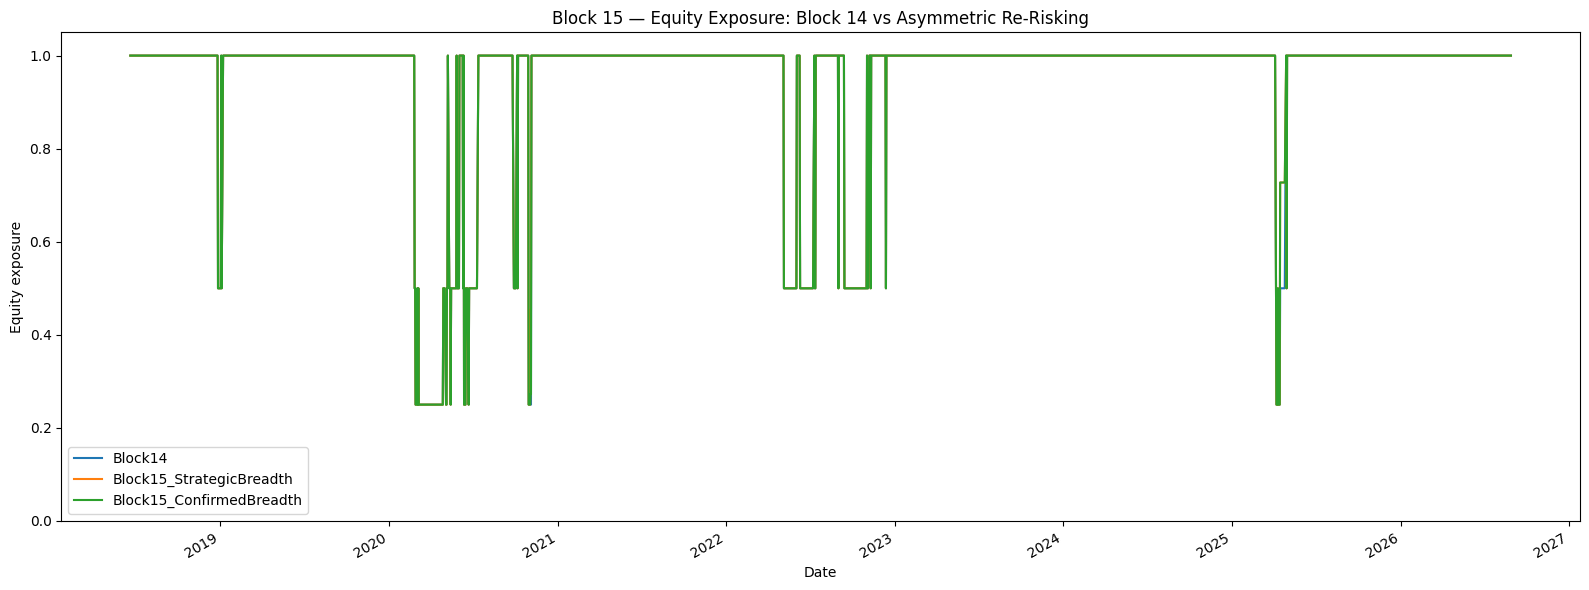

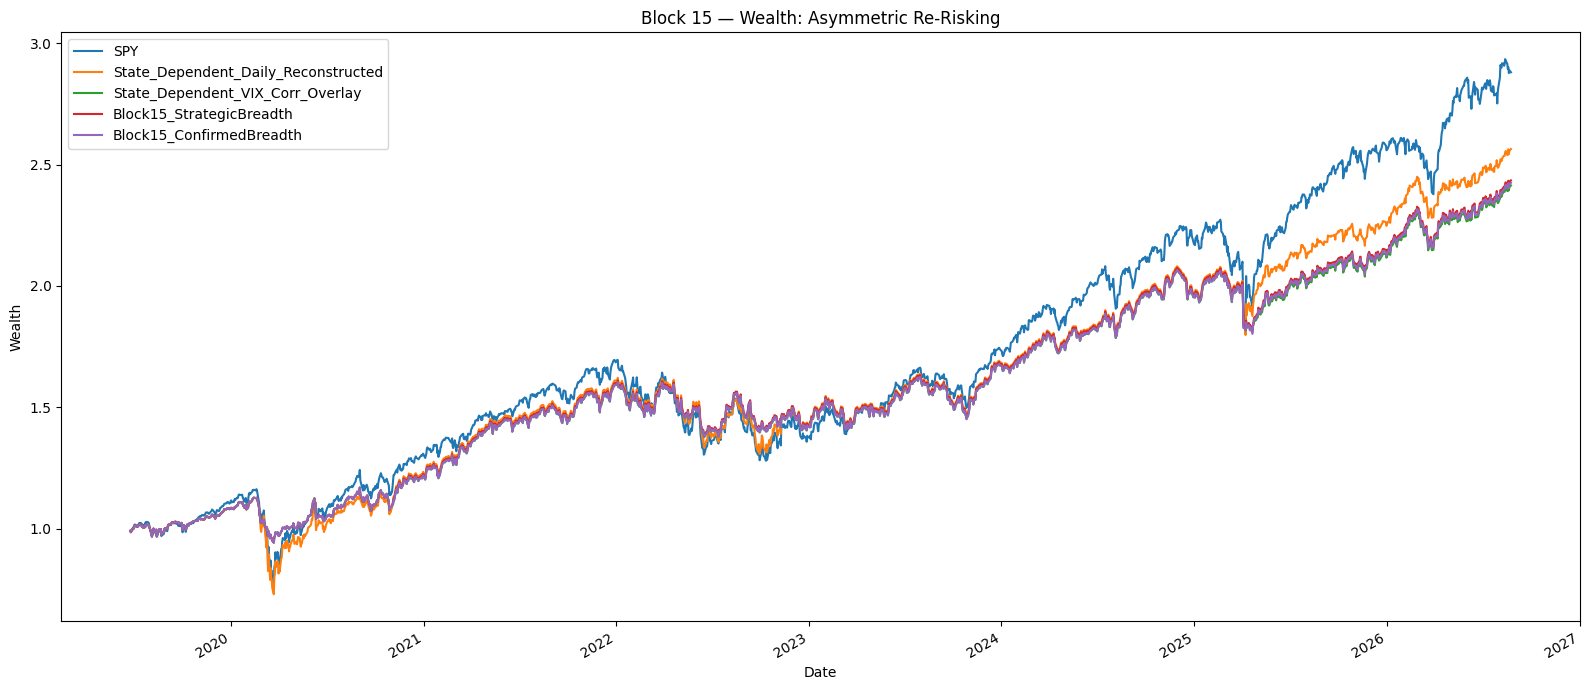

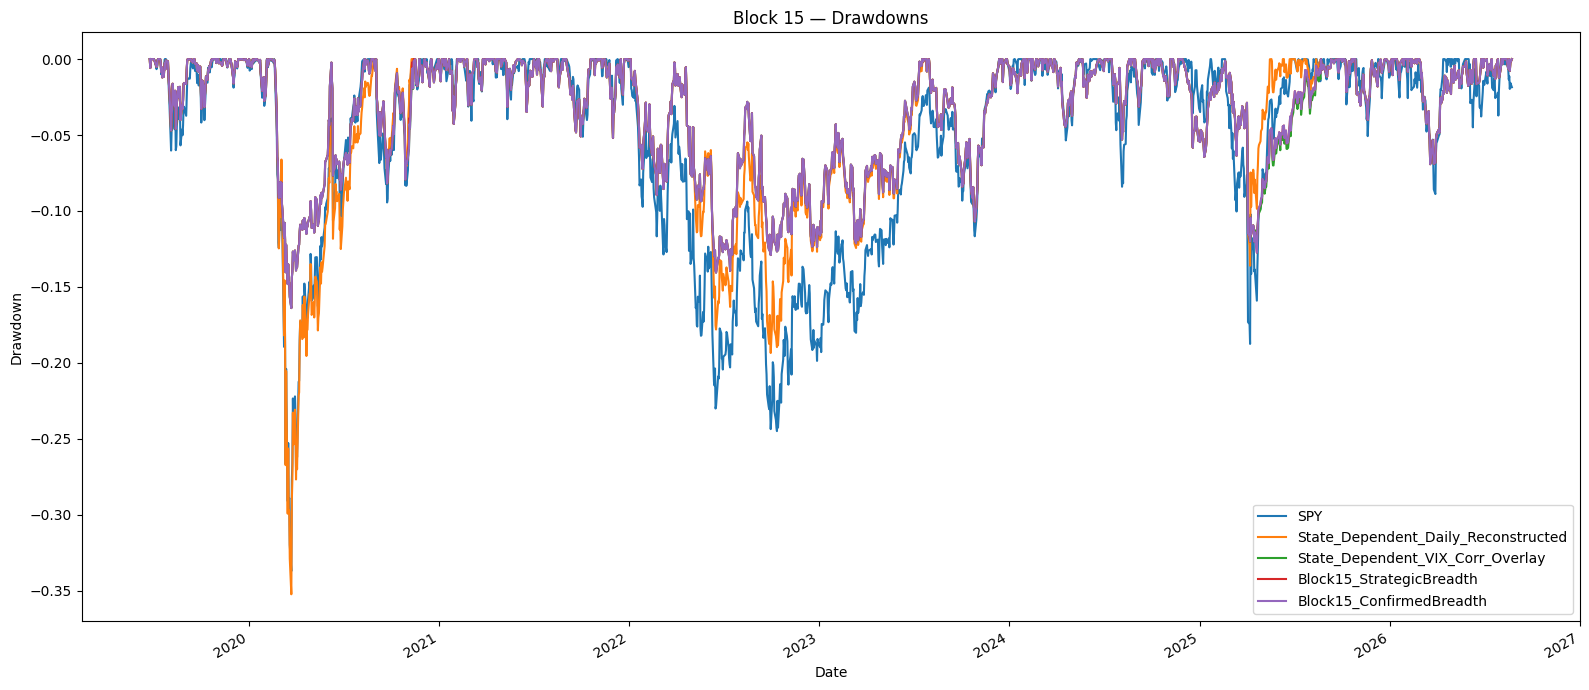

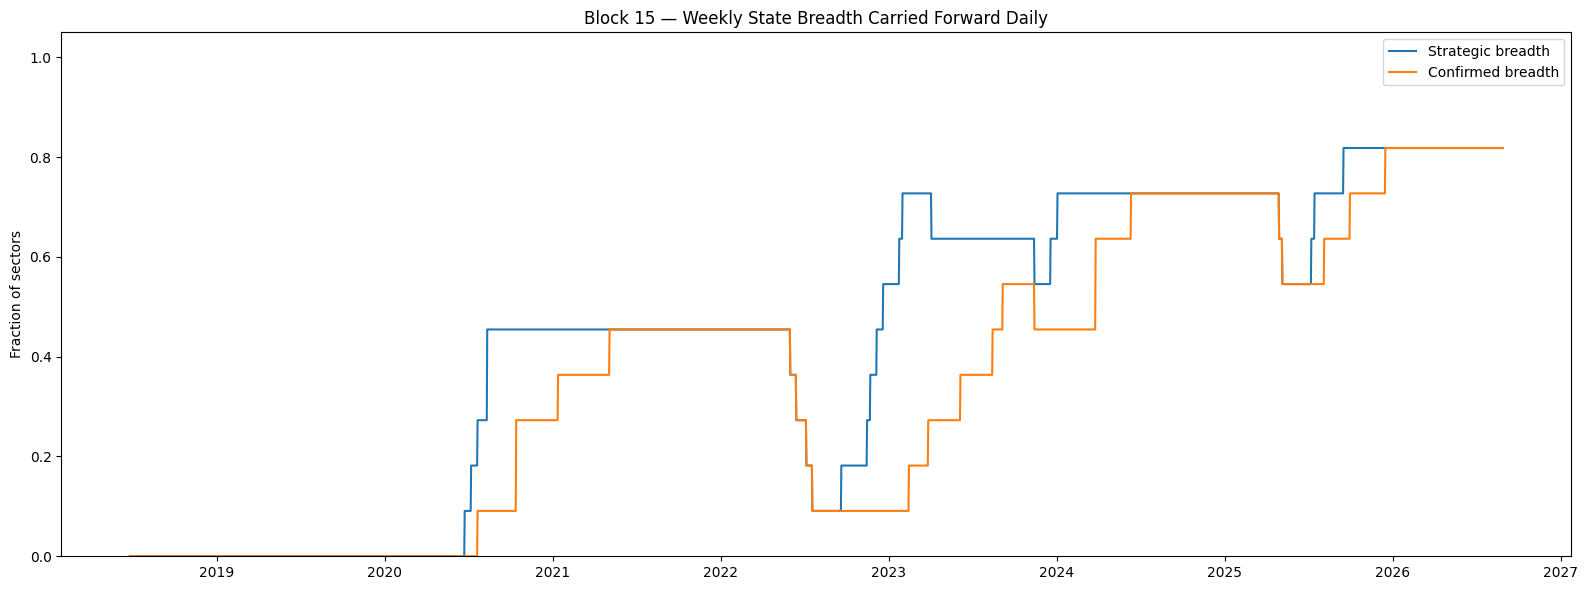

In [13]:
# ============================================================
# BLOCK 15.13 — FIGURES
# ============================================================

fig, ax = plt.subplots(figsize=(16, 6))
exposure_compare.plot(ax=ax)
ax.set_title("Block 15 — Equity Exposure: Block 14 vs Asymmetric Re-Risking")
ax.set_ylabel("Equity exposure")
ax.set_ylim(0, 1.05)
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "block_15_exposure_comparison.png",
    dpi=180,
)
plt.show()

wealth = (1 + comparison).cumprod()

fig, ax = plt.subplots(figsize=(16, 7))
wealth.plot(ax=ax)
ax.set_title("Block 15 — Wealth: Asymmetric Re-Risking")
ax.set_ylabel("Wealth")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "block_15_wealth.png",
    dpi=180,
)
plt.show()

drawdown = wealth.div(wealth.cummax()).sub(1)

fig, ax = plt.subplots(figsize=(16, 7))
drawdown.plot(ax=ax)
ax.set_title("Block 15 — Drawdowns")
ax.set_ylabel("Drawdown")
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "block_15_drawdowns.png",
    dpi=180,
)
plt.show()

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    breadth_daily.index,
    breadth_daily["strategic_breadth"],
    label="Strategic breadth",
)
ax.plot(
    breadth_daily.index,
    breadth_daily["confirmed_breadth"],
    label="Confirmed breadth",
)
ax.set_title("Block 15 — Weekly State Breadth Carried Forward Daily")
ax.set_ylabel("Fraction of sectors")
ax.set_ylim(0, 1.05)
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURE_DIR / "block_15_state_breadth.png",
    dpi=180,
)
plt.show()


In [14]:
# ============================================================
# BLOCK 15.14 — SAVE OUTPUTS & MANIFEST
# ============================================================

PERF_PATH = TABLE_DIR / "block_15_performance.csv"
SCORE_PATH = TABLE_DIR / "block_15_success_scorecard.csv"
COST_PATH = TABLE_DIR / "block_15_cost_sensitivity.csv"
EPISODE_PATH = TABLE_DIR / "block_15_stress_episode_diagnostics.csv"
BREADTH_PATH = OUTPUT_DIR / "block_15_daily_state_breadth.parquet"
EXPOSURE_PATH = OUTPUT_DIR / "block_15_daily_exposures.parquet"
RETURNS_PATH = OUTPUT_DIR / "block_15_daily_returns.parquet"

performance.to_csv(PERF_PATH)
scorecard.to_csv(SCORE_PATH)
cost_sensitivity.to_csv(COST_PATH)
episode_summary.to_csv(EPISODE_PATH, index=False)
breadth_daily.to_parquet(BREADTH_PATH)
exposure_compare.to_parquet(EXPOSURE_PATH)
comparison.to_parquet(RETURNS_PATH)

manifest = {
    "block": 15,
    "title": "Asymmetric Systemic-Risk Overlay: Fast De-Risking, State-Dependent Re-Risking",
    "research_extension": True,
    "blocks_1_to_14_altered": False,
    "signal_parameters_optimized": False,
    "block14_trigger_changed": False,
    "canonical_rerisk_rule": {
        "de_risk_signal": "Frozen Block 14 daily correlation + VIX overlay",
        "rerisk_information": "Fresh post-trigger weekly strategic-state breadth",
        "rerisk_formula": "max(Block14 exposure, strategic breadth)",
        "stale_pre_trigger_state_allowed": False,
        "maximum_equity_exposure": 1.0,
    },
    "robustness_variant": {
        "name": "Confirmed breadth",
        "early_reversal_counts_as_recovered": False,
    },
    "success_criteria": {
        "CAGR_above_Block14": True,
        "Sharpe_minimum_relative_to_Block14": -0.02,
        "Sortino_minimum_relative_to_Block14": -0.05,
        "maximum_drawdown_floor": -0.18,
        "Calmar_minimum": 0.70,
    },
    "saved_files": {
        "performance": str(PERF_PATH),
        "scorecard": str(SCORE_PATH),
        "cost_sensitivity": str(COST_PATH),
        "stress_episodes": str(EPISODE_PATH),
        "daily_breadth": str(BREADTH_PATH),
        "daily_exposures": str(EXPOSURE_PATH),
        "daily_returns": str(RETURNS_PATH),
    },
}

MANIFEST_PATH = (
    MANIFEST_DIR
    / "block_15_asymmetric_systemic_risk_rerisking.json"
)

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

status = pd.DataFrame(
    {"Value": [
        False,
        False,
        False,
        "DAILY",
        "WEEKLY",
        True,
        True,
        True,
        True,
        True,
    ]},
    index=[
        "Blocks 1–14 altered",
        "Existing signal parameters optimized",
        "Block 14 crisis trigger changed",
        "De-risking frequency",
        "Re-risk information frequency",
        "Stale pre-trigger states blocked",
        "Strategic-breadth variant tested",
        "Confirmed-breadth robustness tested",
        "Cost sensitivity saved",
        "All figures saved",
    ],
)

display(status)

print("\nBLOCK 15 COMPLETE")
print("Next: determine whether state-dependent re-risking recovers return")
print("without materially compromising Block 14's downside protection.")


,Value
Blocks 1–14 altered,False
Existing signal parameters optimized,False
Block 14 crisis trigger changed,False
De-risking frequency,DAILY
Re-risk information frequency,WEEKLY
Stale pre-trigger states blocked,True
Strategic-breadth variant tested,True
Confirmed-breadth robustness tested,True
Cost sensitivity saved,True
All figures saved,True



BLOCK 15 COMPLETE
Next: determine whether state-dependent re-risking recovers return
without materially compromising Block 14's downside protection.
